# **PROJECT 1 - Klasifikasi Kualitas Wine Merah**

**Dataset:** Wine Quality - Red Wine  
**Source:** https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009  
**Target:** `quality`   
**Metode:** K-Nearest Neighbors (KNN), Decision Tree, Naive Bayes

---

## Deskripsi Target (Quality Category)
| Kode | Keterangan |
|------|------------|
| Low | Kualitas rendah (quality 3–4) |
| Medium | Kualitas sedang (quality 5–6) |
| High | Kualitas tinggi (quality 7–8) |


## **KELOMPOK 5**

- Tegar Adhi Nugraha Christ During (4222301032)
- Aditya Fajar Shidiq (4222301034)
- Reihan Bagas Ananta (4222301039)
- Muhammad Fadel Umri (4222301053)
- Chairul Azhari (4222301035)


## Preparation

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')
print('Library berhasil di-import!')

Library berhasil di-import!


In [31]:
df = pd.read_csv('winequality-red.csv')
print(f'Shape dataset: {df.shape}')
df.head()

Shape dataset: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


## Exploratory Data Analysis (EDA)

In [33]:
# Statistik deskriptif
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [34]:
# Cek missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
print('Missing Values per Kolom:')
missing_df[missing_df['Missing Count'] > 0]

Missing Values per Kolom:


,Missing Count,Missing (%)


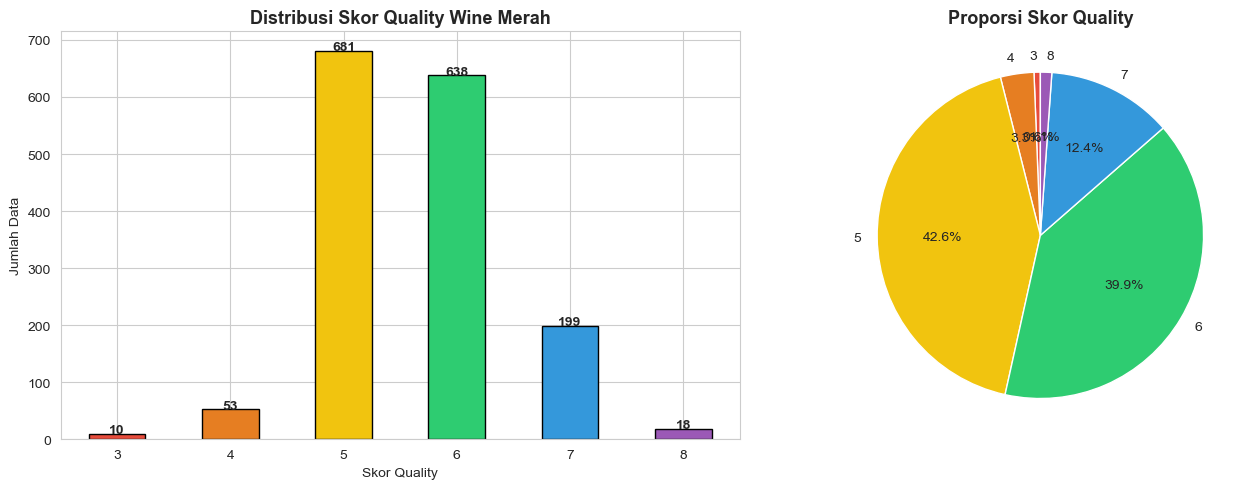


Rentang quality: 3 - 8


In [35]:
# Distribusi kolom Quality (asli)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

quality_counts = df['quality'].value_counts().sort_index()

# Bar plot
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db', '#9b59b6']
quality_counts.plot(kind='bar', ax=axes[0], color=colors[:len(quality_counts)],
                    edgecolor='black', rot=0)
axes[0].set_title('Distribusi Skor Quality Wine Merah', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Skor Quality')
axes[0].set_ylabel('Jumlah Data')
for i, v in enumerate(quality_counts):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(quality_counts, labels=quality_counts.index.astype(str),
            autopct='%1.1f%%', colors=colors[:len(quality_counts)], startangle=90)
axes[1].set_title('Proporsi Skor Quality', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print(f'\nRentang quality: {df["quality"].min()} - {df["quality"].max()}')

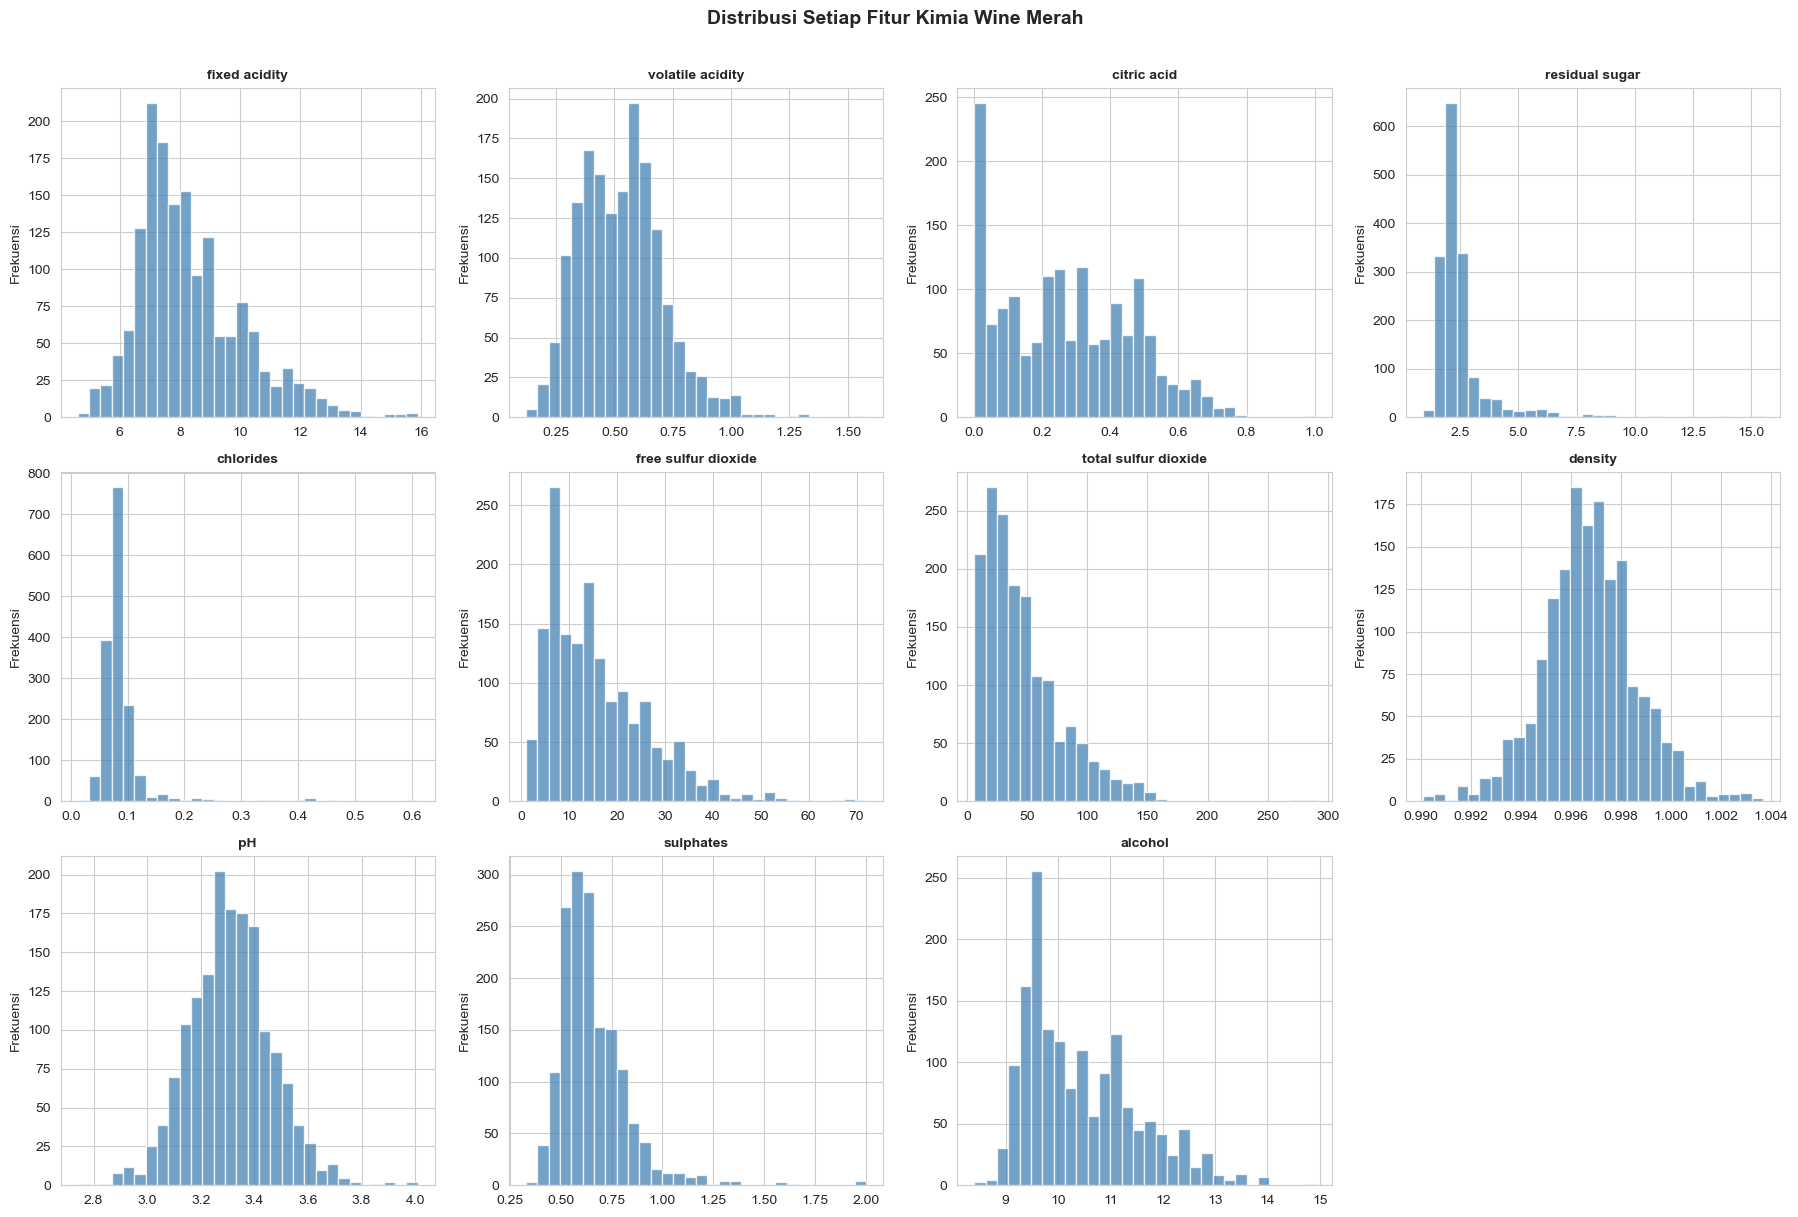

In [36]:
# Distribusi setiap fitur kimia
features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
            'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
            'density', 'pH', 'sulphates', 'alcohol']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(features):
    df[feat].hist(bins=30, ax=axes[i], color='steelblue', alpha=0.75, edgecolor='white')
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Frekuensi')

# Sembunyikan axes kosong
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribusi Setiap Fitur Kimia Wine Merah', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

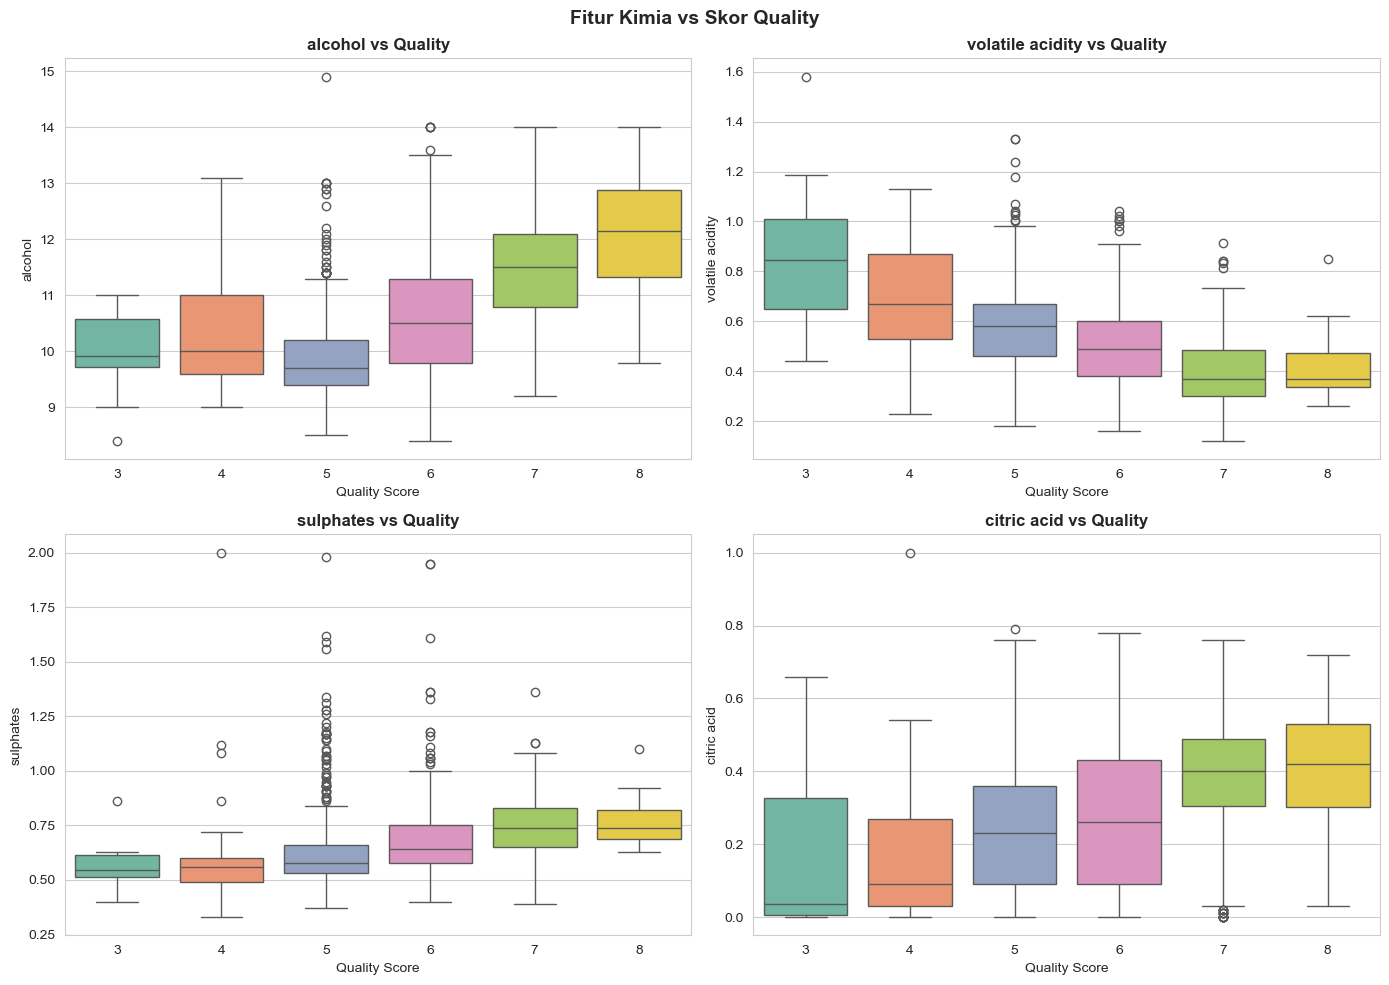

In [37]:
# Boxplot fitur vs quality (pilih beberapa fitur penting)
key_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

palette = sns.color_palette('Set2', n_colors=df['quality'].nunique())
for i, feat in enumerate(key_features):
    sns.boxplot(x='quality', y=feat, data=df, palette='Set2', ax=axes[i])
    axes[i].set_title(f'{feat} vs Quality', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Quality Score')

plt.suptitle('Fitur Kimia vs Skor Quality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

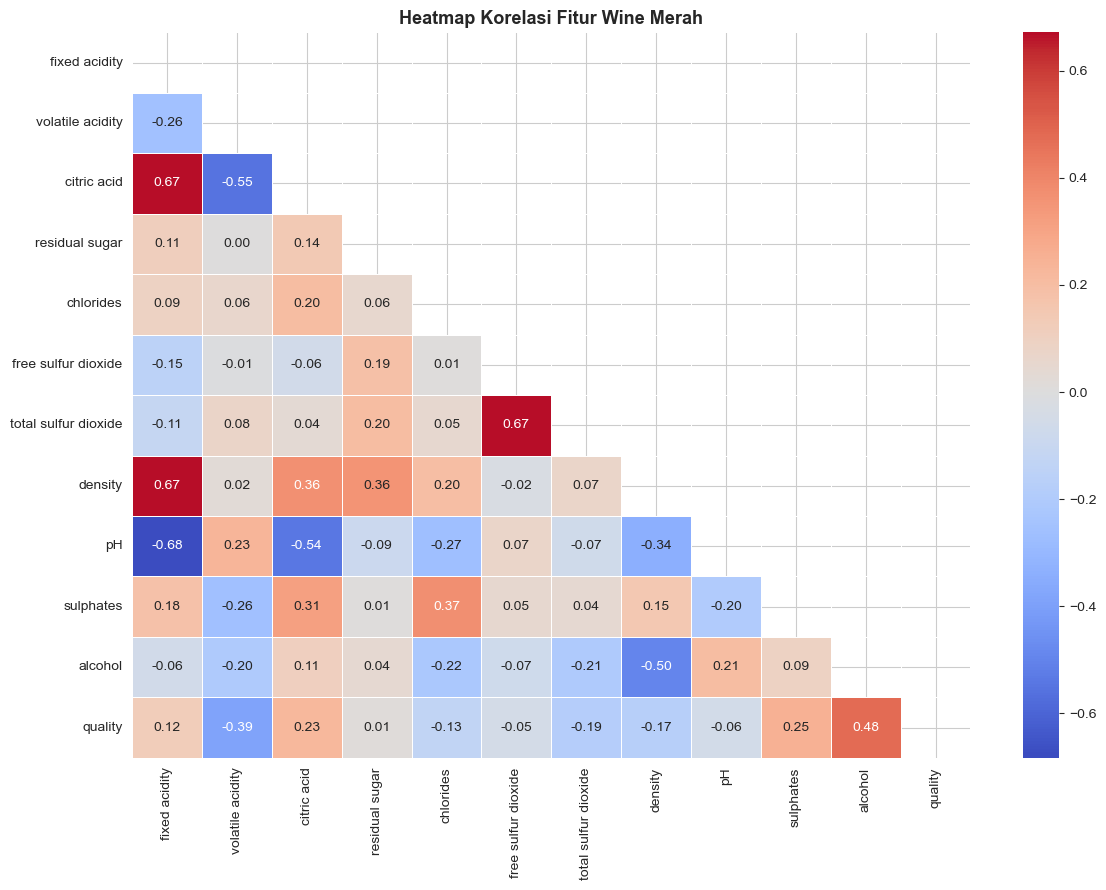

In [38]:
# Heatmap korelasi
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, ax=ax, center=0)
ax.set_title('Heatmap Korelasi Fitur Wine Merah', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Data Preprocessing

### Pembuatan Kolom Target (Quality Category)

Distribusi kategori kualitas:
quality_category
Medium    1319
High       217
Low         63
Name: count, dtype: int64


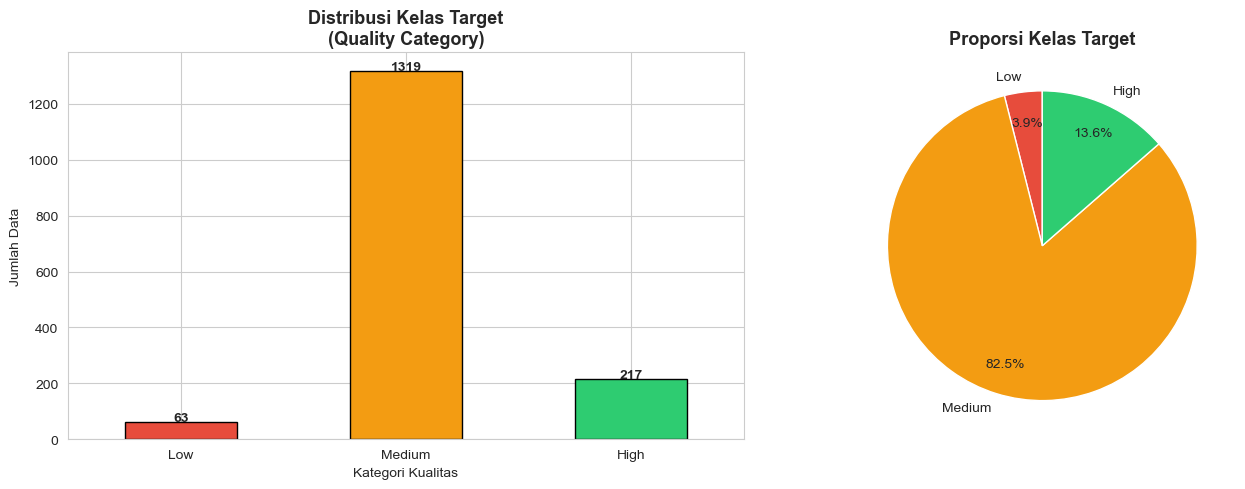

In [39]:
# Buat kategori kualitas dari skor quality
def categorize_quality(q):
    if q <= 4:
        return 'Low'
    elif q <= 6:
        return 'Medium'
    else:
        return 'High'

df['quality_category'] = df['quality'].apply(categorize_quality)

print('Distribusi kategori kualitas:')
print(df['quality_category'].value_counts())

# Visualisasi distribusi kategori target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cat_counts = df['quality_category'].value_counts().reindex(['Low', 'Medium', 'High'])
cat_colors = ['#e74c3c', '#f39c12', '#2ecc71']

cat_counts.plot(kind='bar', ax=axes[0], color=cat_colors, edgecolor='black', rot=0)
axes[0].set_title('Distribusi Kelas Target\n(Quality Category)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Kategori Kualitas')
axes[0].set_ylabel('Jumlah Data')
for i, v in enumerate(cat_counts):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

axes[1].pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%',
            colors=cat_colors, startangle=90, pctdistance=0.8)
axes[1].set_title('Proporsi Kelas Target', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### Seleksi Fitur

In [40]:
FEATURES = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
            'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
            'density', 'pH', 'sulphates', 'alcohol']
TARGET = 'quality_category'

df_model = df[FEATURES + [TARGET]].copy()
print(f'Shape data model: {df_model.shape}')
print(f'\nMissing values:')
print(df_model.isnull().sum())

Shape data model: (1599, 12)

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality_category        0
dtype: int64


### Label Encoding

In [41]:
le = LabelEncoder()

print('Nilai unik target sebelum encoding:')
print(df_model[TARGET].unique())

df_model['target_encoded'] = le.fit_transform(df_model[TARGET])

print('\nMapping Label Encoding:')
for original, encoded in zip(le.classes_, range(len(le.classes_))):
    print(f'  {original} → {encoded}')

df_model.head()

Nilai unik target sebelum encoding:
['Medium' 'High' 'Low']

Mapping Label Encoding:
  High → 0
  Low → 1
  Medium → 2


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality_category,target_encoded
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Medium,2
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Medium,2
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Medium,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Medium,2
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Medium,2


### Train-Test Split

In [42]:
FEATURE_COLS = FEATURES

X = df_model[FEATURE_COLS]
y = df_model['target_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Ukuran data latih  (X_train): {X_train.shape}')
print(f'Ukuran data uji    (X_test) : {X_test.shape}')
print(f'\nDistribusi kelas data latih:')
print(pd.Series(le.inverse_transform(y_train)).value_counts())
print(f'\nDistribusi kelas data uji:')
print(pd.Series(le.inverse_transform(y_test)).value_counts())

Ukuran data latih  (X_train): (1279, 11)
Ukuran data uji    (X_test) : (320, 11)

Distribusi kelas data latih:
Medium    1055
High       174
Low         50
Name: count, dtype: int64

Distribusi kelas data uji:
Medium    264
High       43
Low        13
Name: count, dtype: int64


### StandardScaler

In [43]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURE_COLS)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=FEATURE_COLS)

print('✅ StandardScaler berhasil diterapkan!')
print('\nContoh data setelah scaling (X_train):')
X_train_scaled.head()

✅ StandardScaler berhasil diterapkan!

Contoh data setelah scaling (X_train):


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.638800,0.728392,-1.236114,-0.511083,-0.198972,-0.851599,-1.047561,-0.467980,0.170543,-1.641269,-0.869836
1,-1.278328,0.363648,-1.338241,-0.306884,-0.662899,-1.044062,-1.016712,-1.081842,1.347824,-0.593034,0.923714
2,1.396061,-0.365841,0.602187,-0.374950,-0.557461,-0.851599,-0.955014,0.722377,-0.875930,-0.223069,-0.869836
3,-1.220189,0.419762,-0.980794,-0.374950,0.054079,1.554186,-0.060395,-0.985759,0.889992,-0.469712,0.074138
4,0.233283,-1.319789,1.266017,-0.647215,0.539094,-0.370442,-0.276338,0.081826,-0.418098,-0.469712,-0.869836


## Modeling

### K-Nearest Neighbors (KNN)

In [44]:
clf1 = KNeighborsClassifier()

clf1.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [45]:
y_pred = clf1.predict(X_test)

K terbaik: 13 (Accuracy: 0.8500)


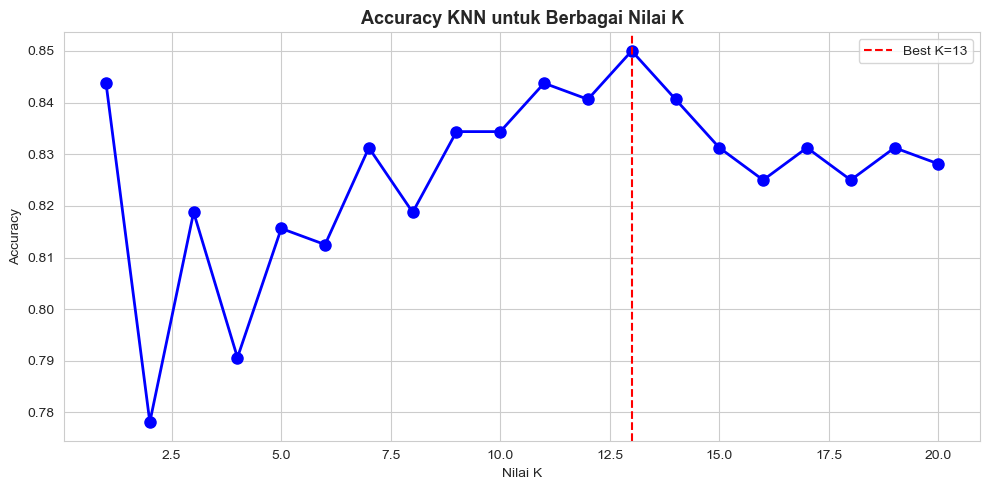

In [46]:
# Mencari nilai K terbaik
k_range = range(1, 21)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    k_scores.append(knn.score(X_test_scaled, y_test))

best_k = k_range[np.argmax(k_scores)]
print(f'K terbaik: {best_k} (Accuracy: {max(k_scores):.4f})')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, k_scores, 'bo-', linewidth=2, markersize=8)
ax.axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k}')
ax.set_title('Accuracy KNN untuk Berbagai Nilai K', fontsize=13, fontweight='bold')
ax.set_xlabel('Nilai K')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [47]:
# Training KNN dengan K terbaik
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, y_pred_knn)
print(f'=== Hasil KNN (K={best_k}) ===')
print(f'Accuracy: {acc_knn:.4f} ({acc_knn*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_knn,
                             target_names=le.classes_))

=== Hasil KNN (K=13) ===
Accuracy: 0.8500 (85.00%)

Classification Report:
              precision    recall  f1-score   support

        High       0.65      0.47      0.54        43
         Low       0.00      0.00      0.00        13
      Medium       0.88      0.95      0.91       264

    accuracy                           0.85       320
   macro avg       0.51      0.47      0.48       320
weighted avg       0.81      0.85      0.83       320



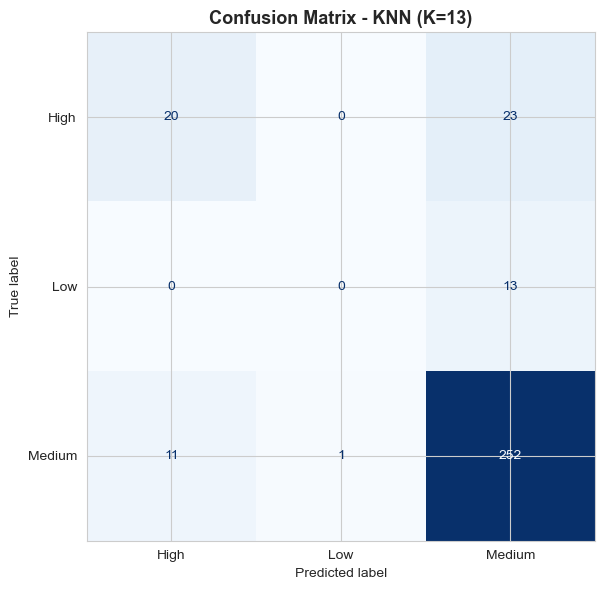

In [48]:
# Confusion Matrix KNN
fig, ax = plt.subplots(figsize=(7, 6))
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn,
                              display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix - KNN (K={best_k})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Decision Tree

In [49]:
# Training Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5, criterion='gini')
dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)

acc_dt = accuracy_score(y_test, y_pred_dt)
print(f'=== Hasil Decision Tree ===')
print(f'Accuracy: {acc_dt:.4f} ({acc_dt*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt,
                             target_names=le.classes_))

=== Hasil Decision Tree ===
Accuracy: 0.8406 (84.06%)

Classification Report:
              precision    recall  f1-score   support

        High       0.59      0.44      0.51        43
         Low       0.00      0.00      0.00        13
      Medium       0.87      0.95      0.91       264

    accuracy                           0.84       320
   macro avg       0.49      0.46      0.47       320
weighted avg       0.80      0.84      0.82       320



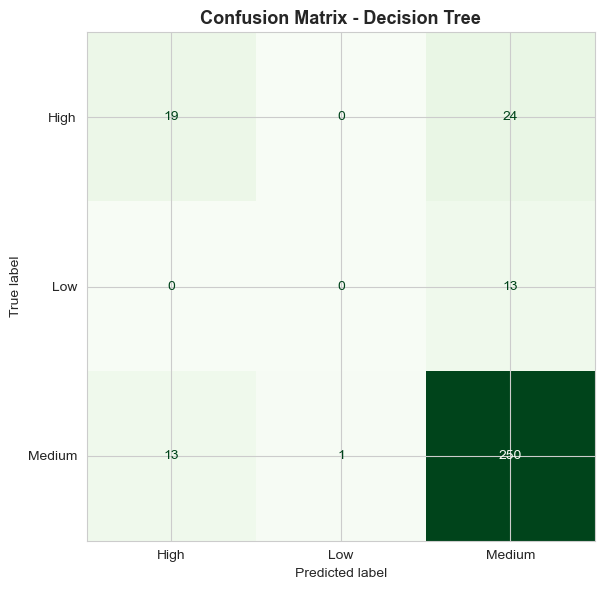

In [50]:
# Confusion Matrix Decision Tree
fig, ax = plt.subplots(figsize=(7, 6))
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt,
                              display_labels=le.classes_)
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Confusion Matrix - Decision Tree', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

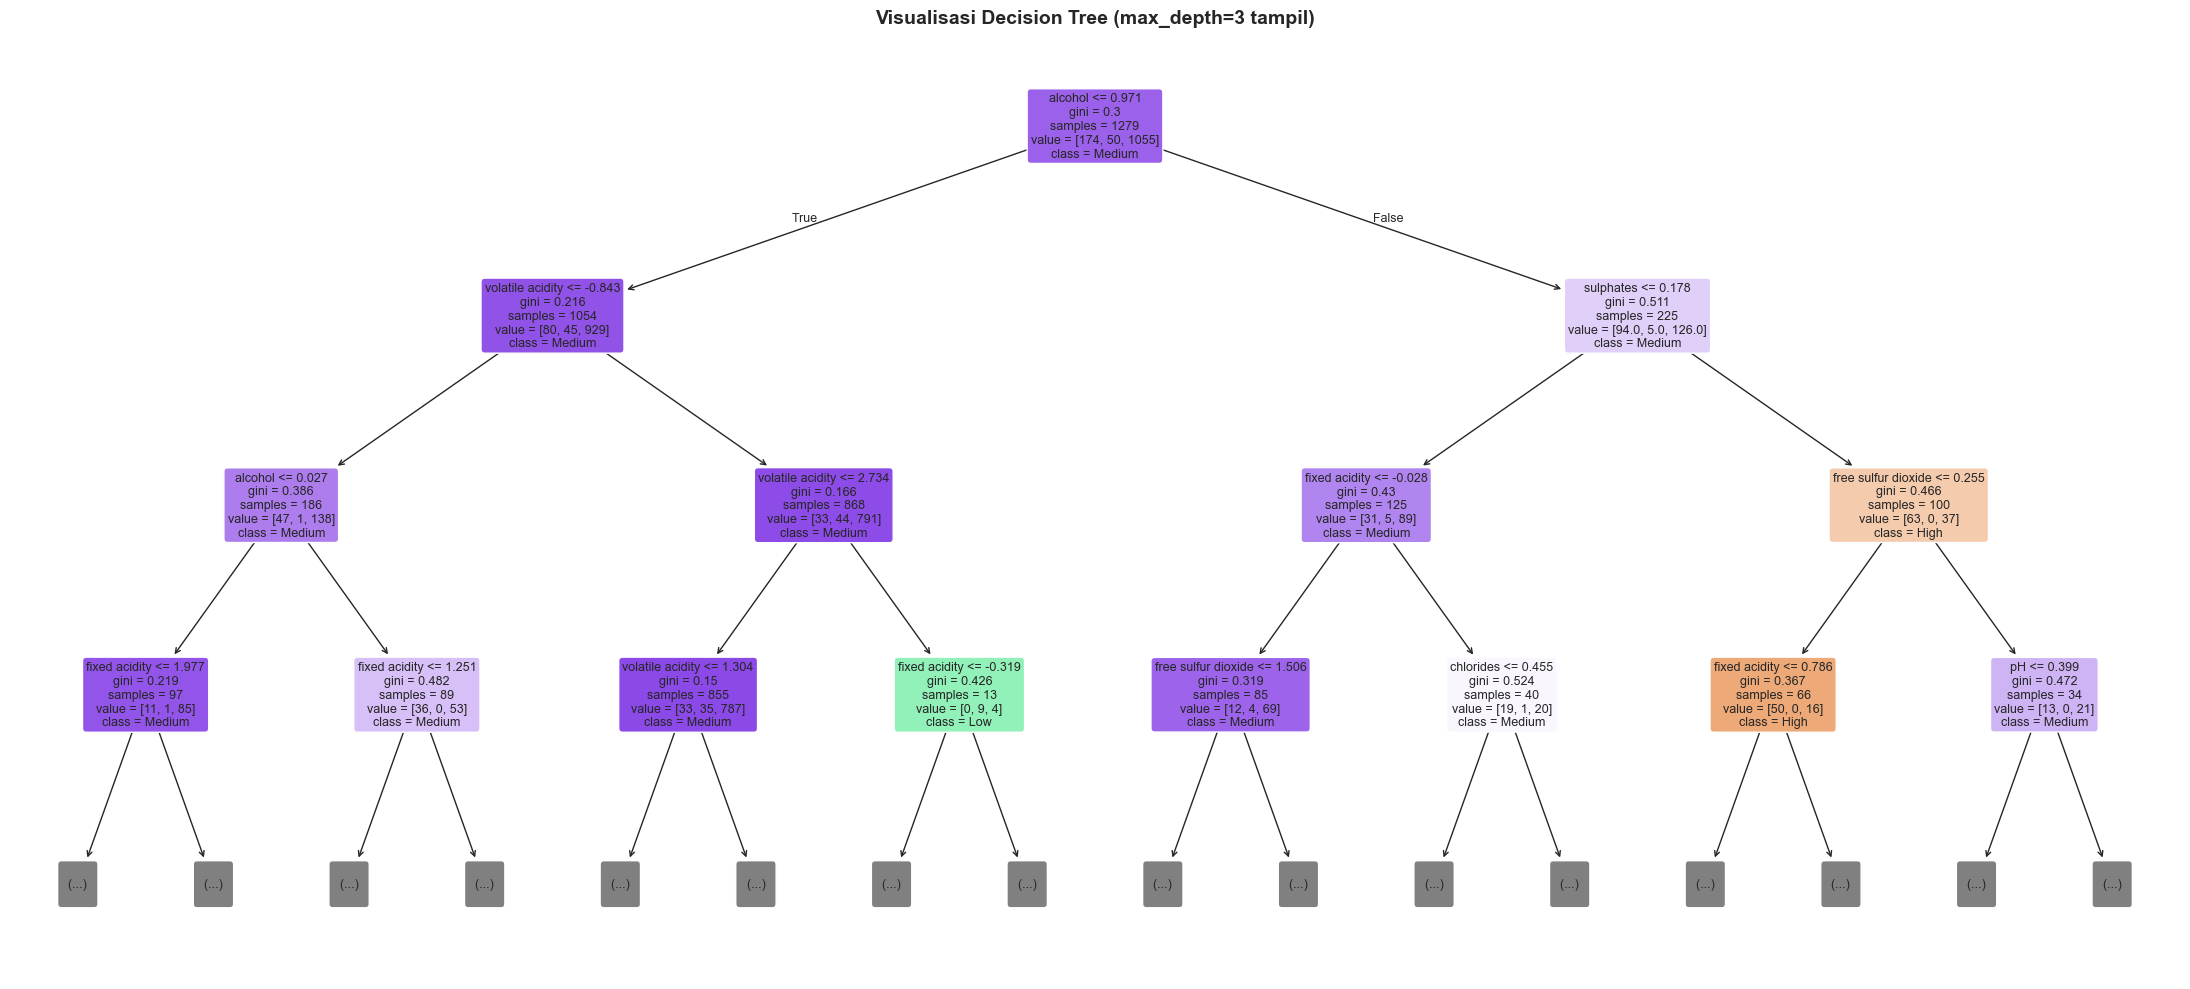

In [51]:
# Visualisasi Decision Tree
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(dt_model, feature_names=FEATURE_COLS,
          class_names=le.classes_,
          filled=True, rounded=True, fontsize=9, ax=ax, max_depth=3)
ax.set_title('Visualisasi Decision Tree (max_depth=3 tampil)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

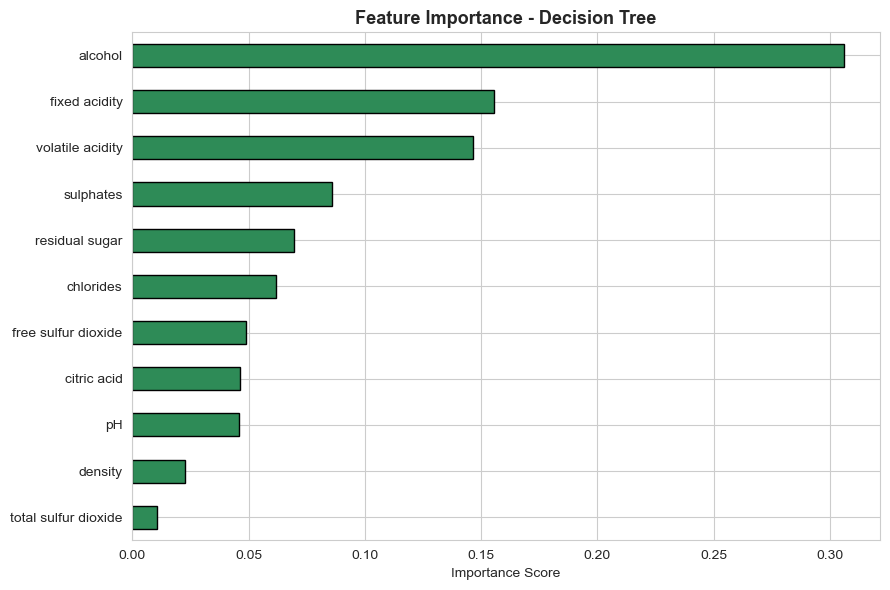

In [52]:
# Feature Importance Decision Tree
importances = pd.Series(dt_model.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
importances.plot(kind='barh', color='seagreen', edgecolor='black', ax=ax)
ax.set_title('Feature Importance - Decision Tree', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

### Naive Bayes

In [53]:
# Training Naive Bayes (Gaussian NB)
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred_nb = nb_model.predict(X_test_scaled)

acc_nb = accuracy_score(y_test, y_pred_nb)
print(f'=== Hasil Naive Bayes ===')
print(f'Accuracy: {acc_nb:.4f} ({acc_nb*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_nb,
                             target_names=le.classes_))

=== Hasil Naive Bayes ===
Accuracy: 0.7531 (75.31%)

Classification Report:
              precision    recall  f1-score   support

        High       0.40      0.58      0.47        43
         Low       0.08      0.08      0.08        13
      Medium       0.88      0.81      0.84       264

    accuracy                           0.75       320
   macro avg       0.45      0.49      0.47       320
weighted avg       0.78      0.75      0.76       320



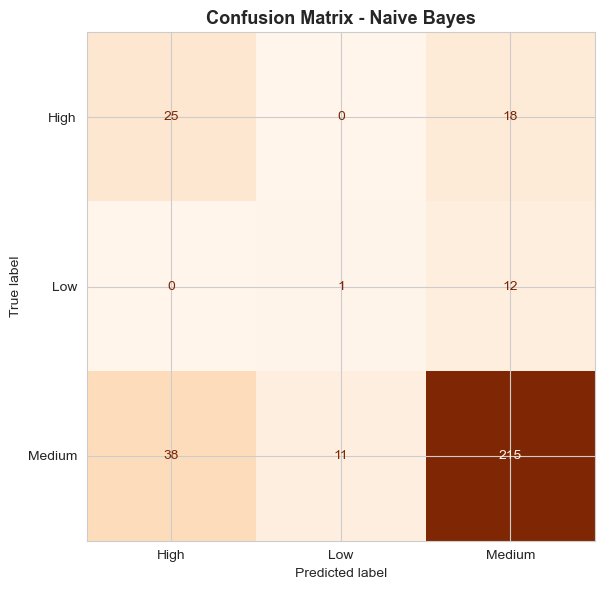

In [54]:
# Confusion Matrix Naive Bayes
fig, ax = plt.subplots(figsize=(7, 6))
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb,
                              display_labels=le.classes_)
disp.plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('Confusion Matrix - Naive Bayes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Perbandingan Performa Semua Model

In [55]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = {
    'Model': ['KNN (K=' + str(best_k) + ')', 'Decision Tree', 'Naive Bayes'],
    'Accuracy': [acc_knn, acc_dt, acc_nb],
    'Precision (macro)': [
        precision_score(y_test, y_pred_knn, average='macro', zero_division=0),
        precision_score(y_test, y_pred_dt,  average='macro', zero_division=0),
        precision_score(y_test, y_pred_nb,  average='macro', zero_division=0)
    ],
    'Recall (macro)': [
        recall_score(y_test, y_pred_knn, average='macro', zero_division=0),
        recall_score(y_test, y_pred_dt,  average='macro', zero_division=0),
        recall_score(y_test, y_pred_nb,  average='macro', zero_division=0)
    ],
    'F1-Score (macro)': [
        f1_score(y_test, y_pred_knn, average='macro', zero_division=0),
        f1_score(y_test, y_pred_dt,  average='macro', zero_division=0),
        f1_score(y_test, y_pred_nb,  average='macro', zero_division=0)
    ]
}

results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.round(4)
print('=== Tabel Perbandingan Model ===')
results_df

=== Tabel Perbandingan Model ===


,Accuracy,Precision (macro),Recall (macro),F1-Score (macro)
Model,,,,
KNN (K=13),0.8500,0.5067,0.4732,0.4845
Decision Tree,0.8406,0.4883,0.4629,0.4714
Naive Bayes,0.7531,0.4526,0.4909,0.4655


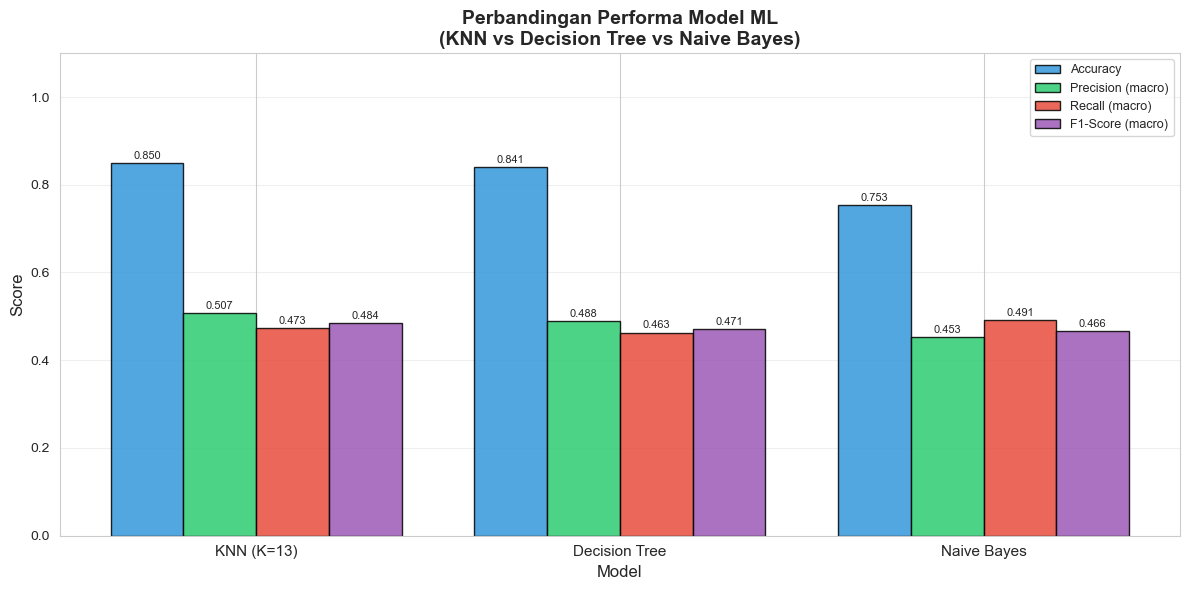

In [56]:
# Visualisasi perbandingan
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results_df.index))
width = 0.2
metrics = results_df.columns.tolist()
palette = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for i, (metric, color) in enumerate(zip(metrics, palette)):
    bars = ax.bar(x + i * width, results_df[metric], width, label=metric, color=color,
                  alpha=0.85, edgecolor='black')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Perbandingan Performa Model ML\n(KNN vs Decision Tree vs Naive Bayes)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df.index, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

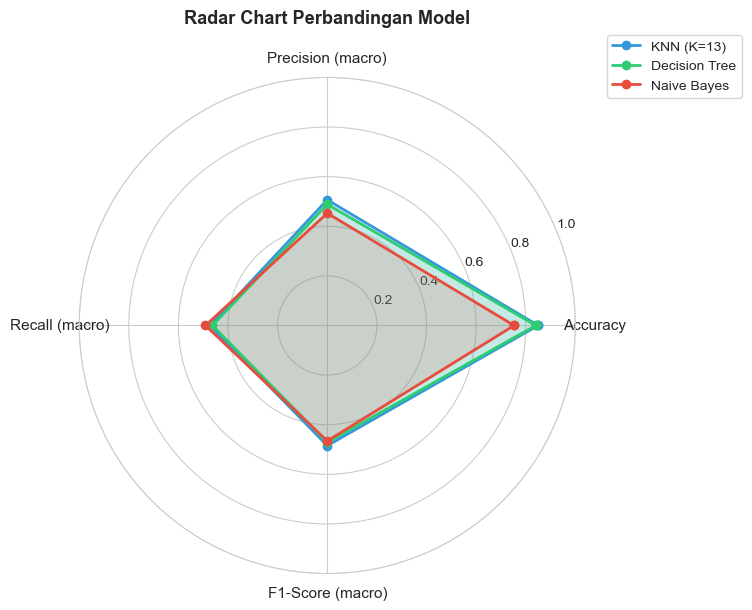

In [57]:
# Radar chart perbandingan model
categories = metrics
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
model_colors = ['#3498db', '#2ecc71', '#e74c3c']

for idx, (model, row) in enumerate(results_df.iterrows()):
    values = row.values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=model_colors[idx])
    ax.fill(angles, values, alpha=0.15, color=model_colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_ylim(0, 1)
ax.set_title('Radar Chart Perbandingan Model', size=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

## Kesimpulan

In [58]:
best_model_name = results_df['Accuracy'].idxmax()
best_acc = results_df['Accuracy'].max()

print('=' * 55)
print('       RINGKASAN HASIL KLASIFIKASI')
print('=' * 55)
print(f'Dataset       : Wine Quality - Red Wine')
print(f'Jumlah data   : {df_model.shape[0]} baris')
print(f'Fitur         : {len(FEATURE_COLS)} fitur kimia')
print(f'Target        : Quality Category (3 kelas: Low, Medium, High)')
print(f'Train/Test    : 80% / 20%')
print('-' * 55)
print(f'{"Model":<25} {"Accuracy":>10}')
print('-' * 55)
for model, row in results_df.iterrows():
    mark = ' ⭐' if model == best_model_name else ''
    print(f'{model:<25} {row["Accuracy"]:>10.4f}{mark}')
print('-' * 55)
print(f'Model Terbaik : {best_model_name}')
print(f'Accuracy      : {best_acc:.4f} ({best_acc*100:.2f}%)')
print('=' * 55)

       RINGKASAN HASIL KLASIFIKASI
Dataset       : Wine Quality - Red Wine
Jumlah data   : 1599 baris
Fitur         : 11 fitur kimia
Target        : Quality Category (3 kelas: Low, Medium, High)
Train/Test    : 80% / 20%
-------------------------------------------------------
Model                       Accuracy
-------------------------------------------------------
KNN (K=13)                    0.8500 ⭐
Decision Tree                 0.8406
Naive Bayes                   0.7531
-------------------------------------------------------
Model Terbaik : KNN (K=13)
Accuracy      : 0.8500 (85.00%)
